# RNN人名分类案例

In [30]:
# 导入torch工具
import torch
# 导入nn准备构建模型
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
# 导入torch的数据源 数据迭代器工具包
from torch.utils.data import Dataset, DataLoader
# 用于获得常见字母及字符规范化
import string
# 导入时间工具包
import time
# 引入制图工具包
import matplotlib.pyplot as plt
# 进度条工具
from tqdm import tqdm
import json

# 获取所有常用字符包括字母和常用标点
all_letters = string.ascii_letters + " .,;'"
# 获取常用字符数量
n_letters = len(all_letters) # 57
print("n_letter:", n_letters)
# 国家名 种类数
categorys = ['Italian', 'English', 'Arabic', 'Spanish', 'Scottish', 'Irish', 'Chinese', 'Vietnamese', 'Japanese',
             'French', 'Greek', 'Dutch', 'Korean', 'Polish', 'Portuguese', 'Russian', 'Czech', 'German']
# 国家名 个数
categorynum = len(categorys)
print('categorys--->', categorys)# 国家名 种类数

n_letter: 57
categorys---> ['Italian', 'English', 'Arabic', 'Spanish', 'Scottish', 'Irish', 'Chinese', 'Vietnamese', 'Japanese', 'French', 'Greek', 'Dutch', 'Korean', 'Polish', 'Portuguese', 'Russian', 'Czech', 'German']


In [6]:
# 读取人名分类数据：数据读取到内存
def read_data(filename):
    my_list_x, my_list_y = [],[]

    with open(filename, mode="r", encoding="utf-8") as f:
        lines = f.readlines()
        # print(lines)
        for line in lines:
            line = line.strip() # 去除左右空格
            if line:
                name, label = line.split("\t")
                my_list_x.append(name)
                my_list_y.append(label)

    return my_list_x, my_list_y


my_list_x, my_list_y = read_data("./assets/name_classfication.txt")
print("my_list_x：",my_list_x)
print("my_list_y：",my_list_y)

my_list_x： ['Abl', 'Adsit', 'Ajdrna', 'Alt', 'Antonowitsch', 'Antonowitz', 'Bacon', 'Ballalatak', 'Ballaltick', 'Bartonova', 'Bastl', 'Baroch', 'Benesch', 'Betlach', 'Biganska', 'Bilek', 'Blahut', 'Blazek', 'Blazek', 'Blazejovsky', 'Blecha', 'Bleskan', 'Blober', 'Bock', 'Bohac', 'Bohunovsky', 'Bolcar', 'Borovka', 'Borovski', 'Borowski', 'Borovsky', 'Brabbery', 'Brezovjak', 'Brousil', 'Bruckner', 'Buchta', 'Cablikova', 'Camfrlova', 'Cap', 'Cerda', 'Cermak', 'Chermak', 'Cermak', 'Cernochova', 'Cernohous', 'Cerny', 'Cerney', 'Cerny', 'Cerv', 'Cervenka', 'Chalupka', 'Charlott', 'Chemlik', 'Chicken', 'Chilar', 'Chromy', 'Cihak', 'Clineburg', 'Klineberg', 'Cober', 'Colling', 'Cvacek', 'Czabal', 'Damell', 'Demall', 'Dehmel', 'Dana', 'Dejmal', 'Dempko', 'Demko', 'Dinko', 'Divoky', 'Dolejsi', 'Dolezal', 'Doljs', 'Dopita', 'Drassal', 'Driml', 'Duyava', 'Dvorak', 'Dziadik', 'Egr', 'Entler', 'Faltysek', 'Faltejsek', 'Fencl', 'Fenyo', 'Fillipova', 'Finfera', 'Finferovy', 'Finke', 'Fojtikova', 'Frem

In [7]:
# 构建数据源NameClassDataset
class NameClassDataset(Dataset):
    def __init__(self, my_list_x, my_list_y):
        # 样本x
        self.my_list_x = my_list_x
        # 对应的标签y
        self.my_list_y = my_list_y
        self.sample_len = len(my_list_x)

    # 获取样本条数
    def __len__(self):
        return self.sample_len

    # 获取第几条样本数据
    def __getitem__(self, index):
        # 对index异常值进行修正 [0, self.sample_len-1]
        index = min(max(index, 0), self.sample_len - 1)

        x = self.my_list_x[index]
        y = self.my_list_y[index]

        """
        将样本x转换为one-hot编码
        以Alice为例：Alice可以看成是一个句子，每个字符都是一个分词
        将名字进行拆分 A - l - i - c - e
        每个字符都可以看成是一个one-hot编码
        总共有n_letters个字符，one-hot编码的维度为n_letters
        """
        # 形状为二维，第一维表示名字的所有字符向量，第二维表示每个字符的one-hot编码
        tensor_x = torch.zeros(len(x), n_letters)
        for index, char in enumerate(x):
            idx = all_letters.find(char)  # 字符在57个字符中的索引
            tensor_x[index][idx] = 1

        # 样本y 张量化
        tensor_y = torch.tensor(categorys.index(y), dtype=torch.long)
        return tensor_x, tensor_y

my_list_x, my_list_y = read_data("./assets/name_classfication.txt")
dataset = NameClassDataset(my_list_x, my_list_y)
print(dataset[0])
# mydataloader = DataLoader(dataset=dataset, batch_size=1, shuffle=True)

# for  i, (x, y) in enumerate (mydataloader):
#     print('x.shape', x.shape, x) (1, 8, 57) (批量数，序列长度，向量维度)
#     print('y.shape', y.shape, y)
#     break

(tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]]), tensor(16))


In [8]:
"""
由于序列分词长度，例如Alice 是5个字符，而Bob是3个字符
（batch_size, seq_len, input_size）seq_len不一样，不能做batch操作
这里没有做padding填充，所以batch_size只能传1
"""

def get_dataloader(batch_size=1):
    my_list_x, my_list_y = read_data("./assets/name_classfication.txt")
    dataset = NameClassDataset(my_list_x, my_list_y)
    dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)
    return dataloader

# RNN模型构建

In [ ]:
class RNNNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.num_layers = num_layers
        # 定义RNN层
        self.rnn = nn.RNN(input_size, hidden_size, num_layers)

        # 定义linear层
        # 最后一个分词的隐藏层输出作为全连接层的输入
        self.linear = nn.Linear(self.hidden_size, self.output_size)

        # 定义softmax层，按列进行softmax操作
        self.softmax = nn.LogSoftmax(dim=-1)

    def forward(self, input, hidden):
        # print("input.shape", input.shape)  # 输入数据形状：(7, 1, 57)
        # print("hidden.shape", hidden.shape)  # 隐藏状态形状：(1, 1, 128)
        # 输入input的形状为 (sequence_length, batch_size, input_size)
        # 隐藏状态hidden的形状为 (num_layers, batch_size, hidden_size)
        # output和输入数据形状一致
        output, hn = self.rnn(input, hidden)
        # 获取最后一个分词的隐藏层输出张量作为全连接层的输入（其实就是hn）
        # temp = hn.squeeze(0)  # 移除第0个维度，形状从(1, 1, 128)变为(1, 128)
        temp = output[-1, :, :]  # -1表示当前维度取最后一个
        # print("temp.shape", temp.shape)  # 形状：(1, 128)
        result = self.linear(temp)

        return self.softmax(result), hn

    def init_hidden(self, batch_size=1):
        # 初始化隐藏层输入数据
        return torch.zeros(self.num_layers, batch_size, self.hidden_size)


# 测试RNNNet
rnn_net = RNNNet(input_size=57, hidden_size=128, output_size=18, num_layers=1)
mydataloader = get_dataloader(batch_size=1)

for x, y in mydataloader:
    print("x.shape", x.shape)  # 数据形状：(1, 7, 57)
    print("y.shape", y.shape)
    # 因为没有设置batch_first=True，所以默认是(sequence_length, batch_size, input_size)
    x = x.transpose(0, 1)  # 转换为 (7, 1, 57)
    hidden = rnn_net.init_hidden(batch_size=1)
    output, hn = rnn_net(x, hidden)
    print("output.shape", output.shape)  # 输出形状：(1, 18)
    print("hn.shape", hn.shape)  # 隐藏状态形状：(1, 1, 128)
    break

x.shape torch.Size([1, 9, 57])
y.shape torch.Size([1])
output.shape torch.Size([1, 18])
hn.shape torch.Size([1, 1, 128])


# LSTM模型构建

In [10]:
class LSTMNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.num_layers = num_layers
        # 定义LSTM层
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers)

        # 定义linear层
        # 最后一个分词的隐藏层输出作为全连接层的输入
        self.linear = nn.Linear(self.hidden_size, self.output_size)

        # 定义softmax层，按列进行softmax操作
        self.softmax = nn.LogSoftmax(dim=-1)

    def forward(self, input, hidden, c):
        # print("input.shape", input.shape)  # 输入数据形状：(7, 1, 57)
        # print("hidden.shape", hidden.shape)  # 隐藏状态形状：(1, 1, 128)
        # 输入input的形状为 (sequence_length, batch_size, input_size)
        # 隐藏状态hidden的形状为 (num_layers, batch_size, hidden_size)
        # output和输入数据形状一致
        output, (hn, cn) = self.lstm(input, (hidden, c))
        # 获取最后一个分词的隐藏层输出张量作为全连接层的输入（其实就是hn）
        # temp = hn.squeeze(0)  # 移除第0个维度，形状从(1, 1, 128)变为(1, 128)
        temp = output[-1, :, :]  # -1表示当前维度取最后一个
        # print("temp.shape", temp.shape)  # 形状：(1, 128)
        result = self.linear(temp)

        return self.softmax(result), hn, cn

    def init_hidden(self, batch_size=1):
        # 初始化隐藏层输入数据
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        return h0, c0

# GRU模型构建


In [18]:
class GRUNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.num_layers = num_layers
        # 定义GRU层
        self.gru = nn.GRU(input_size, hidden_size, num_layers)

        # 定义linear层
        # 最后一个分词的隐藏层输出作为全连接层的输入
        self.linear = nn.Linear(self.hidden_size, self.output_size)

        # 定义softmax层，按列进行softmax操作
        self.softmax = nn.LogSoftmax(dim=-1)

    def forward(self, input, hidden):
        # print("input.shape", input.shape)  # 输入数据形状：(7, 1, 57)
        # print("hidden.shape", hidden.shape)  # 隐藏状态形状：(1, 1, 128)
        # 输入input的形状为 (sequence_length, batch_size, input_size)
        # 隐藏状态hidden的形状为 (num_layers, batch_size, hidden_size)
        # output和输入数据形状一致
        output, hn = self.gru(input, hidden)
        # 获取最后一个分词的隐藏层输出张量作为全连接层的输入（其实就是hn）
        # temp = hn.squeeze(0)  # 移除第0个维度，形状从(1, 1, 128)变为(1, 128)
        temp = output[-1, :, :]  # -1表示当前维度取最后一个
        # print("temp.shape", temp.shape)  # 形状：(1, 128)
        result = self.linear(temp)

        return self.softmax(result), hn

    def init_hidden(self, batch_size=1):
        # 初始化隐藏层输入数据
        return torch.zeros(self.num_layers, batch_size, self.hidden_size)

# 模型训练

## RNN模型训练

In [36]:
def train_rnn():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"当前设备为：{device}")
    input_size = 57
    hidden_size = 128
    output_size = 18
    num_layers = 1
    my_rnn = RNNNet(input_size, hidden_size, output_size, num_layers).to(device)
    dataloder = get_dataloader(batch_size=1)

    # 损失函数
    criterion = nn.NLLLoss()
    # 优化器
    adam = optim.Adam(my_rnn.parameters(), lr=0.001)

    # 定义模型训练参数
    starttime = time.time()
    total_iter_num = 0  # 已训练的样本数
    total_loss = 0.0  # 已训练的损失和
    total_loss_list = []  # 每100个样本求一次平均损失 形成损失列表
    total_acc_num = 0  # 已训练样本预测准确总数
    total_acc_list = []  # 每100个样本求一次平均准确率 形成平均准确率列表

    epochs = 1
    for epoch in range(epochs):
        my_rnn.train()
        for x, y in tqdm(dataloder):
            # x形状为(batch_size, sequence_length, input_size)
            # 交换为(sequence_length, batch_size, input_size)
            x = x.transpose(0, 1)
            x = x.to(device)
            # print(x.shape)  # 形状：(..., 1, 57)
            y = y.to(device)
            hidden = my_rnn.init_hidden()
            hidden = hidden.to(device)
            output, hn = my_rnn(x, hidden)
            # print(output.shape)  # 形状：(1, 18)，对应18个分类
            # print(y.shape) # 形状：(1,)
            loss = criterion(output, y)

            # 反向传播
            adam.zero_grad()
            loss.backward()
            adam.step()

            total_iter_num = total_iter_num + 1  # 统计样本数
            total_loss = total_loss + loss.item()

            # 样本正确个数
            total_acc_num = (
                total_acc_num + (torch.argmax(output, dim=1) == y).sum().item()
            )

            # 每100次训练 求一次平均损失 平均准确率
            if total_iter_num % 100 == 0:
                avg_loss = total_loss / total_iter_num
                avg_acc = total_acc_num / total_iter_num
                total_loss_list.append(avg_loss)
                total_acc_list.append(avg_acc)

            # 每2000次训练 打印日志
            if total_iter_num % 2000 == 0:
                print(
                    "轮次：%d，损失：%.6f,准确率：%.3f,时间：%d秒"
                    % (epoch + 1, avg_loss, avg_acc, time.time() - starttime)
                )

    torch.save(
        my_rnn.state_dict(),
        "./model/rnn_model.pth",
    )

    # 计算总时间
    total_time = time.time() - starttime
    print("训练完成，耗时：%d秒" % total_time)

    # 将训练的结果进行保存
    dict1 = {
        "total_loss_list": total_loss_list,
        "total_acc_list": total_acc_list,
        "total_time": total_time,
    }
    with open("./model/rnn_model.json", "w") as f:
        f.write(json.dumps(dict1))

    return total_loss_list, total_time, total_acc_list
train_rnn()

当前设备为：cuda


 10%|█         | 2068/20074 [00:04<00:38, 471.72it/s]

轮次：1，损失：1.558436,准确率：0.533,时间：4秒


 20%|██        | 4067/20074 [00:08<00:31, 509.74it/s]

轮次：1，损失：1.405056,准确率：0.583,时间：8秒


...

 90%|████████▉ | 18060/20074 [00:36<00:04, 495.43it/s]

轮次：1，损失：1.147674,准确率：0.656,时间：36秒


100%|██████████| 20074/20074 [00:40<00:00, 490.42it/s]

轮次：1，损失：1.136019,准确率：0.660,时间：40秒
训练完成，耗时：40秒


([2.2499108082056045,
  2.0501562625169756,
  1.912397873327136,
  1.8916002476401628,
  1.8833187517523766,
  1.8587520168970029,
  1.8407530633785896,
  1.7891743439994752,
  1.761397937287887,
  1.7231296364814044,
  1.7034093131565236,
  1.6658784015763861,
  1.6497872494318737,
  1.6482375065969037,
  1.6337209978327154,
  1.6104537738949876,
  1.5999704396837007,
  1.5794427240037152,
  1.5678754911846235,
  1.558436366659589,
  1.558870848540128,
  1.5458077413832176,
  1.5332925392876622,
  1.526864173770009,
  1.5192099103375338,
  1.506738660918871,
  1.4893242898439834,
  1.4785214086207061,
  1.468432187798176,
  1.459492922534293,
  1.4579212677652098,
  1.455557001496545,
  1.4539332424224687,
  1.4449198425235055,
  1.441105435432783,
  1.4378840781154416,
  1.427250244610556,
  1.4211183017537174,
  1.4140338493042584,
  1.4050555542875227,
  1.401873063468275,
  1.3962327546341111,
  1.3947317418002059,
  1.3884077648562114,
  1.3817206553737373,
  1.3809684127881243,


## LSTM模型训练

In [37]:
def train_lstm():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"当前设备为：{device}")
    input_size = 57
    hidden_size = 128
    output_size = 18
    num_layers = 1
    my_rnn = LSTMNet(input_size, hidden_size, output_size, num_layers).to(device)
    dataloder = get_dataloader(batch_size=1)

    # 损失函数
    criterion = nn.NLLLoss()
    # 优化器
    adam = optim.Adam(my_rnn.parameters(), lr=0.001)

    # 定义模型训练参数
    starttime = time.time()
    total_iter_num = 0  # 已训练的样本数
    total_loss = 0.0  # 已训练的损失和
    total_loss_list = []  # 每100个样本求一次平均损失 形成损失列表
    total_acc_num = 0  # 已训练样本预测准确总数
    total_acc_list = []  # 每100个样本求一次平均准确率 形成平均准确率列表

    epochs = 1
    for epoch in range(epochs):
        my_rnn.train()
        for x, y in tqdm(dataloder):
            # x形状为(batch_size, sequence_length, input_size)
            # 交换为(sequence_length, batch_size, input_size)
            x = x.transpose(0, 1)
            x = x.to(device)
            # print(x.shape)  # 形状：(..., 1, 57)
            y = y.to(device)
            hidden, c = my_rnn.init_hidden()
            hidden = hidden.to(device)
            c = c.to(device)
            output, hn, cn = my_rnn(x, hidden, c)
            # print(output.shape)  # 形状：(1, 18)，对应18个分类
            # print(y.shape) # 形状：(1,)
            loss = criterion(output, y)

            # 反向传播
            adam.zero_grad()
            loss.backward()
            adam.step()

            total_iter_num = total_iter_num + 1  # 统计样本数
            total_loss = total_loss + loss.item()

            # 样本正确个数
            total_acc_num = (
                total_acc_num + (torch.argmax(output, dim=1) == y).sum().item()
            )

            # 每100次训练 求一次平均损失 平均准确率
            if total_iter_num % 100 == 0:
                avg_loss = total_loss / total_iter_num
                avg_acc = total_acc_num / total_iter_num
                total_loss_list.append(avg_loss)
                total_acc_list.append(avg_acc)

            # 每2000次训练 打印日志
            if total_iter_num % 2000 == 0:
                print(
                    "轮次：%d，损失：%.6f,准确率：%.3f,时间：%d秒"
                    % (epoch + 1, avg_loss, avg_acc, time.time() - starttime)
                )

    torch.save(
        my_rnn.state_dict(),
        "./model/lstm_model.pth",
    )

    # 计算总时间
    total_time = time.time() - starttime
    print("训练完成，耗时：%d秒" % total_time)

    # 将训练的结果进行保存
    dict1 = {
        "total_loss_list": total_loss_list,
        "total_acc_list": total_acc_list,
        "total_time": total_time,
    }
    with open("./model/lstm_model.json", "w") as f:
        f.write(json.dumps(dict1))

    return total_loss_list, total_time, total_acc_list

train_lstm()

当前设备为：cuda


 10%|█         | 2057/20074 [00:04<00:32, 554.56it/s]

轮次：1，损失：1.620456,准确率：0.529,时间：3秒


 20%|██        | 4055/20074 [00:07<00:28, 557.44it/s]

轮次：1，损失：1.423957,准确率：0.584,时间：7秒


...

 90%|█████████ | 18080/20074 [00:34<00:03, 546.96it/s]

轮次：1，损失：1.048223,准确率：0.690,时间：34秒


100%|██████████| 20074/20074 [00:38<00:00, 524.16it/s]

轮次：1，损失：1.020682,准确率：0.698,时间：38秒
训练完成，耗时：38秒


([2.277449000477791,
  2.054527062177658,
  1.9157619556039571,
  1.9039866935648024,
  1.8970200433284043,
  1.8245169856585561,
  1.8171865068003534,
  1.821980228452012,
  1.8009811453376379,
  1.783488078268245,
  1.7637148004719478,
  1.7438647442807753,
  1.730549592011823,
  1.7103953750880567,
  1.6885798141940807,
  1.6658203662009328,
  1.6581170142120134,
  1.6400597916322295,
  1.6259757713773777,
  1.620455962356762,
  1.603244049482247,
  1.5897852653583555,
  1.5778790790708128,
  1.578742114419098,
  1.5664463153355754,
  1.556408891791048,
  1.540454472694546,
  1.523014263257667,
  1.5152581907663463,
  1.5055006156978974,
  1.492958592696138,
  1.479045411371426,
  1.4725555580644338,
  1.4647868125381887,
  1.457557850358958,
  1.4492793421121153,
  1.4435470333199387,
  1.4379595678917125,
  1.431516660741599,
  1.423957111405136,
  1.4196739385125834,
  1.415386165628207,
  1.4070667750715025,
  1.4007037962044837,
  1.3926109008012701,
  1.3874232445277923,
  1.3

## GRU模型训练

In [40]:
def train_gru():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"当前设备为：{device}")
    input_size = 57
    hidden_size = 128
    output_size = 18
    num_layers = 1
    my_rnn = GRUNet(input_size, hidden_size, output_size, num_layers).to(device)
    dataloder = get_dataloader(batch_size=1)

    # 损失函数
    criterion = nn.NLLLoss()
    # 优化器
    adam = optim.Adam(my_rnn.parameters(), lr=0.001)

    # 定义模型训练参数
    starttime = time.time()
    total_iter_num = 0  # 已训练的样本数
    total_loss = 0.0  # 已训练的损失和
    total_loss_list = []  # 每100个样本求一次平均损失 形成损失列表
    total_acc_num = 0  # 已训练样本预测准确总数
    total_acc_list = []  # 每100个样本求一次平均准确率 形成平均准确率列表

    epochs = 1
    for epoch in range(epochs):
        my_rnn.train()
        for x, y in tqdm(dataloder):
            # x形状为(batch_size, sequence_length, input_size)
            # 交换为(sequence_length, batch_size, input_size)
            x = x.transpose(0, 1)
            x = x.to(device)
            # print(x.shape)  # 形状：(..., 1, 57)
            y = y.to(device)
            hidden = my_rnn.init_hidden()
            hidden = hidden.to(device)
            output, hn = my_rnn(x, hidden)
            # print(output.shape)  # 形状：(1, 18)，对应18个分类
            # print(y.shape) # 形状：(1,)
            loss = criterion(output, y)

            # 反向传播
            adam.zero_grad()
            loss.backward()
            adam.step()

            total_iter_num = total_iter_num + 1  # 统计样本数
            total_loss = total_loss + loss.item()

            # 样本正确个数
            total_acc_num = (
                total_acc_num + (torch.argmax(output, dim=1) == y).sum().item()
            )

            # 每100次训练 求一次平均损失 平均准确率
            if total_iter_num % 100 == 0:
                avg_loss = total_loss / total_iter_num
                avg_acc = total_acc_num / total_iter_num
                total_loss_list.append(avg_loss)
                total_acc_list.append(avg_acc)

            # 每2000次训练 打印日志
            if total_iter_num % 2000 == 0:
                print(
                    "轮次：%d，损失：%.6f,准确率：%.3f,时间：%d秒"
                    % (epoch + 1, avg_loss, avg_acc, time.time() - starttime)
                )

    torch.save(
        my_rnn.state_dict(),
        "./model/gru_model.pth",
    )

    # 计算总时间
    total_time = time.time() - starttime
    print("训练完成，耗时：%d秒" % total_time)

    # 将训练的结果进行保存
    dict1 = {
        "total_loss_list": total_loss_list,
        "total_acc_list": total_acc_list,
        "total_time": total_time,
    }
    with open("./model/gru_model.json", "w") as f:
        f.write(json.dumps(dict1))

    return total_loss_list, total_time, total_acc_list


train_gru()

当前设备为：cuda


  0%|          | 0/20074 [00:00<?, ?it/s]

 10%|█         | 2105/20074 [00:04<00:33, 535.66it/s]

轮次：1，损失：1.508010,准确率：0.553,时间：3秒


 20%|██        | 4060/20074 [00:07<00:27, 586.69it/s]

...

 90%|████████▉ | 18056/20074 [00:33<00:04, 493.96it/s]

轮次：1，损失：0.963994,准确率：0.711,时间：33秒


100%|██████████| 20074/20074 [00:37<00:00, 540.88it/s]

轮次：1，损失：0.943698,准确率：0.717,时间：36秒
训练完成，耗时：37秒


([2.245713568106294,
  2.0094256353750826,
  1.9610985878358285,
  1.9374387804418802,
  1.8830347670316696,
  1.8438312650130442,
  1.8271461114074503,
  1.7860182808176615,
  1.753785121532985,
  1.7256874068761245,
  1.686404185346751,
  1.6610790492025747,
  1.633938545074063,
  1.6035125532266516,
  1.5951578017242718,
  1.5728823688701596,
  1.553798026524806,
  1.542068621585786,
  1.5138373126019111,
  1.5080098580353078,
  1.4930165131268691,
  1.4832427039788507,
  1.4771971831639277,
  1.4643104856427331,
  1.4520361682895804,
  1.4510482254268628,
  1.4456566094506005,
  1.440871300050411,
  1.4331606382392708,
  1.426193577919097,
  1.4111553608928995,
  1.4043196007261032,
  1.4018371841543755,
  1.3963599999737242,
  1.3855849052237879,
  1.3688398619317013,
  1.3623496988542831,
  1.3525909081218215,
  1.3428106553312944,
  1.3345125642514686,
  1.33008498932521,
  1.3229422069047618,
  1.3204775635717467,
  1.3123899963488526,
  1.3054072743568168,
  1.2948376121981267

# 绘制对比图

当前设备为：cuda


 10%|█         | 2036/20074 [00:04<00:37, 482.38it/s]

轮次：1，损失：1.566886,准确率：0.523,时间：4秒


 20%|██        | 4112/20074 [00:08<00:28, 567.26it/s]

轮次：1，损失：1.451922,准确率：0.558,时间：8秒


...

轮次：1，损失：0.995970,准确率：0.704,时间：31秒


 90%|█████████ | 18086/20074 [00:35<00:03, 575.67it/s]

轮次：1，损失：0.966965,准确率：0.713,时间：35秒


100%|██████████| 20074/20074 [00:38<00:00, 515.70it/s]

轮次：1，损失：0.942620,准确率：0.720,时间：38秒
训练完成，耗时：38秒


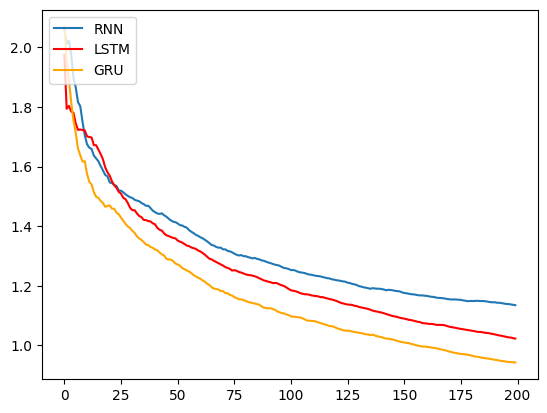

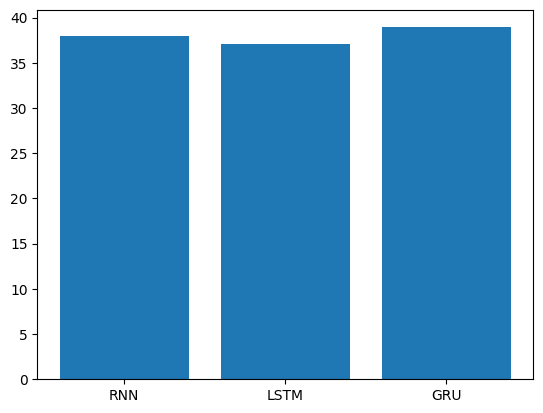

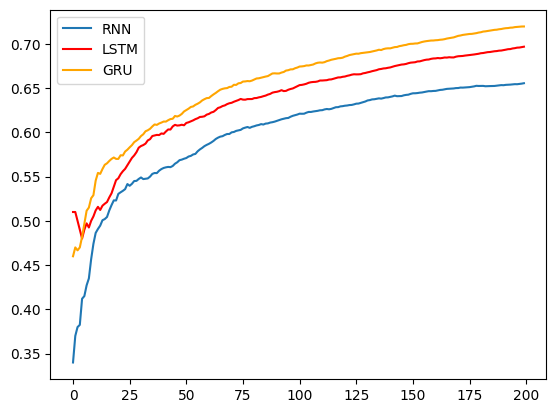

In [41]:
total_loss_list_rnn, total_time_rnn, total_acc_list_rnn = train_rnn()
total_loss_list_lstm, total_time_lstm, total_acc_list_lstm = train_lstm()
total_loss_list_gru, total_time_gru, total_acc_list_gru = train_gru()


# 绘制损失对比曲线
# 创建画布0
plt.figure(0)
plt.plot(total_loss_list_rnn, label="RNN")
plt.plot(total_loss_list_lstm, color="red", label="LSTM")
plt.plot(total_loss_list_gru, color="orange", label="GRU")
plt.legend(loc='upper left')
plt.savefig('./model/loss.png')
plt.show()

# 绘制柱状图
# 创建画布1
plt.figure(1)
x_data = ["RNN", "LSTM", "GRU"]
y_data = [total_time_rnn, total_time_lstm, total_time_gru]
# 绘制训练耗时对比柱状图
plt.bar(range(len(x_data)), y_data, tick_label=x_data)
plt.savefig('./model/time.png')
plt.show()

 # 绘制准确率对比曲线
plt.figure(2)
plt.plot(total_acc_list_rnn, label="RNN")
plt.plot(total_acc_list_lstm, color="red", label="LSTM")
plt.plot(total_acc_list_gru, color="orange", label="GRU")
plt.legend(loc='upper left')
plt.savefig('./model/acc.png')
plt.show()

# 模型预测

In [55]:
# topk的使用
tensor = torch.randn(2, 3)
print(tensor)
# 从tensor中取出前2名
# 参数1：表示取出前两名
# 参数2：表示要排序的维度
# 参数3：表示是否返回最大或是最下的元素

topv, topi = tensor.topk(2, 1, True)
print(topv)
print(topi)
"""
tensor([[0.8617, 0.1408, 1.3098],
        [0.3079, 0.1149, 0.9925]])
tensor([[1.3098, 0.8617],
        [0.9925, 0.3079]])
tensor([[2, 0],
        [2, 0]])
"""

# 将人名转化为onehot张量
# eg 'bai' --> [3,57]
def nameToTensor(name):
    # 文本张量化x
    tensor_x = torch.zeros(len(name), n_letters)
    # 遍历这个人名中的每个字符索引和字符
    for li, letter in enumerate(name):
        # letter在字符串all_letters中的位置 就是onehot张量1索引的位置
        # letter在字符串all_letters中的位置 使用字符串find()方法获取
        tensor_x[li][all_letters.find(letter)] = 1

    return tensor_x


# 构建预测函数
def predict_rnn(name):
    n_letters = 57
    n_hidden = 128
    n_categories = 18

    # 输入文本, 张量化one-hot
    x_tensor = nameToTensor(name)
    x_tensor = x_tensor.unsqueeze(1)  # 增加一个batch维度 [seq_len, 1, n_letters]
    my_rnn = RNNNet(n_letters, n_hidden, n_categories)
    my_rnn.load_state_dict(torch.load("./model/rnn_model.pth"))

    with torch.no_grad():
        output, hidden = my_rnn(x_tensor, my_rnn.init_hidden())
        print(output)

        # 从预测结果中取出前3名
        # 3表示取前3名, 1表示要排序的维度, True表示是否返回最大或是最下的元素
        topv, topi = output.topk(3, 1, True)

        for i in range(3):
            value = topv[0][i]
            index = topi[0][i]
            category = categorys[index]
            print(f"概率第{i+1}名: {category}，value:{value}")


def predict_lstm(name):
    n_letters = 57
    n_hidden = 128
    n_categories = 18

    # 输入文本, 张量化one-hot
    x_tensor = nameToTensor(name)
    x_tensor = x_tensor.unsqueeze(1)  # 增加一个batch维度 [seq_len, 1, n_letters]
    my_lstm = LSTMNet(n_letters, n_hidden, n_categories)
    my_lstm.load_state_dict(torch.load("./model/lstm_model.pth"))

    with torch.no_grad():
        hidden, c = my_lstm.init_hidden()
        output, hn, cn = my_lstm(x_tensor, hidden, c)
        print(output)

        # 从预测结果中取出前3名
        # 3表示取前3名, 1表示要排序的维度, True表示是否返回最大或是最下的元素
        topv, topi = output.topk(3, 1, True)

        for i in range(3):
            value = topv[0][i]
            index = topi[0][i]
            category = categorys[index]
            print(f"概率第{i+1}名: {category}，value:{value}")


def predict_gru(name):
    n_letters = 57
    n_hidden = 128
    n_categories = 18

    # 输入文本, 张量化one-hot
    x_tensor = nameToTensor(name)
    x_tensor = x_tensor.unsqueeze(1)  # 增加一个batch维度 [seq_len, 1, n_letters]
    my_gru = GRUNet(n_letters, n_hidden, n_categories)
    my_gru.load_state_dict(torch.load("./model/gru_model.pth"))

    with torch.no_grad():
        output, hidden = my_gru(x_tensor, my_gru.init_hidden())
        print(output)

        # 从预测结果中取出前3名
        # 3表示取前3名, 1表示要排序的维度, True表示是否返回最大或是最下的元素
        topv, topi = output.topk(3, 1, True)

        for i in range(3):
            value = topv[0][i]
            index = topi[0][i]
            category = categorys[index]
            print(f"概率第{i+1}名: {category}，value:{value}")


predict_rnn("zhang")
predict_lstm("zhang")
predict_gru("zhang")

predict_gru("kuang")


tensor([[-0.4417, -0.7425,  0.2960],
        [-1.8699, -0.7557, -0.1172]])
tensor([[ 0.2960, -0.4417],
        [-0.1172, -0.7557]])
tensor([[2, 0],
        [2, 1]])
tensor([[-3.9595, -3.0240, -8.8817, -6.2816, -5.7422, -7.1130, -0.3140, -3.6112,
         -6.3422, -5.7064, -6.1933, -4.7827, -3.5130, -7.8055, -8.8136, -2.3837,
         -6.3452, -3.5427]])
概率第1名: Chinese，value:-0.31400614976882935
概率第2名: Russian，value:-2.3837497234344482
概率第3名: English，value:-3.024049758911133
tensor([[-6.5923, -2.4465, -5.0088, -6.0874, -5.6423, -4.7080, -0.5486, -2.3483,
         -5.1021, -4.0891, -6.3168, -4.4296, -3.1598, -7.6081, -7.0116, -2.4217,
         -5.9481, -3.0907]])
概率第1名: Chinese，value:-0.5486414432525635
概率第2名: Vietnamese，value:-2.3483076095581055
概率第3名: Russian，value:-2.4216597080230713
tensor([[-7.8930, -2.7304, -5.2760, -6.4980, -6.3342, -3.5813, -0.9794, -3.0563,
         -6.3870, -5.6651, -7.7875, -4.5555, -3.6678, -8.5776, -8.6502, -1.0022,
         -5.2749, -2.7896]])
概率第1名: Chines